# Day 4 — Model Integration & Error Analysis
## Melanoma Skin Cancer Dataset — Benign vs Malignant

### Learning Objectives

By the end of this notebook, we will:

- Integrate preprocessing and the trained model into one end-to-end prediction flow.
- Use the **same preprocessing function** during training and prediction.
- Understand and prevent **training/serving skew**.
- Evaluate the model with a confusion matrix.
- Identify the model's most common error type.
- Inspect at least three misclassified examples.
- Categorize each error as a possible **data issue** or **model weakness**.
- Build a reusable `predict()` function that accepts a raw image path.


##  Project Overview

This notebook continues the **Melanoma Skin Cancer — Benign vs Malignant** project from Day 3.

Day 3 focused mainly on image preprocessing with OpenCV:

- Reading images
- Resizing
- BGR → RGB conversion
- Pixel normalization
- Reusable preprocessing
- Image augmentation

In Day 4, the goal is to connect these pieces into one complete workflow:

**Raw image → preprocessing → model → prediction**

This integration makes the project easier to evaluate and later deploy.


##  Dataset

We use the same dataset as Day 3:

**Melanoma Skin Cancer Dataset — Benign vs Malignant**

The expected structure is similar to:

```text
dataset/
├── train/
│   ├── benign/
│   └── malignant/
└── test/
    ├── benign/
    └── malignant/
```



##  Import Libraries

In [1]:
!pip -q install kagglehub opencv-python seaborn
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)


TensorFlow version: 2.20.0
OpenCV version: 5.0.0


##  Download / Locate the Dataset

In [2]:
import kagglehub

DATASET_HANDLE = "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"

try:
    dataset_root = Path(
        kagglehub.dataset_download(DATASET_HANDLE)
    )
    print("Dataset root:", dataset_root)
except Exception as e:
    print("Automatic download failed.")
    print("Error:", e)
    dataset_root = Path("/content")


100%|██████████| 79.4M/79.4M [00:01<00:00, 75.3MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1


##  Find Train and Test Folders

The exact folder names can vary slightly depending on how Kaggle extracts the dataset, so this helper searches for folders named `train` and `test`.


In [28]:
def find_split_folder(root, split_name):
    root = Path(root)

    matches = [
        p for p in root.rglob("*")
        if p.is_dir() and p.name.lower() == split_name.lower()
    ]

    if not matches:
        raise FileNotFoundError(
            f"Could not find a '{split_name}' folder under {root}"
        )

    return matches[0]


train_dir = find_split_folder(dataset_root, "train")
test_dir = find_split_folder(dataset_root, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)


Train directory: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/train
Test directory: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test


##  Inspect Class Folders

In [4]:
CLASS_NAMES = ["Benign", "Malignant"]

for split_dir in [train_dir, test_dir]:
    print(f"\n{split_dir}")
    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        count = len(list(class_dir.glob("*"))) if class_dir.exists() else 0
        print(f"  {class_name}: {count} files")



/root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/train
  Benign: 6289 files
  Malignant: 5590 files

/root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test
  Benign: 1000 files
  Malignant: 1000 files


##  Configuration

We use a fixed image size so every image has the same shape before entering the neural network.

The labels are:

- `0` → benign
- `1` → malignant


In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = ["Benign", "Malignant"]
CLASS_TO_LABEL = {name: index for index, name in enumerate(CLASS_NAMES)}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Image size:", IMG_SIZE)
print("Class mapping:", CLASS_TO_LABEL)


Image size: (128, 128)
Class mapping: {'Benign': 0, 'Malignant': 1}


##  The Shared Preprocessing Function

This is one of the most important cells in Day 4.

The **same preprocessing function** must be used when:

1. Preparing training data.
2. Preparing test data.
3. Preparing a new image for prediction.

This prevents **training/serving skew**.

The function performs:

1. Read image with OpenCV.
2. Convert BGR → RGB.
3. Resize to `128 × 128`.
4. Convert pixels to `float32`.
5. Normalize pixels to `[0, 1]`.


In [6]:
def preprocess_image(image_path, img_size=IMG_SIZE):
    """Read one raw image and apply the single preprocessing pipeline."""
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, img_size, interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32) / 255.0

    return image

sample_files = list((train_dir / "Benign").glob("*"))
if sample_files:
    sample_image = preprocess_image(sample_files[0])
    print("Processed shape:", sample_image.shape)
    print("Minimum pixel value:", sample_image.min())
    print("Maximum pixel value:", sample_image.max())


Processed shape: (128, 128, 3)
Minimum pixel value: 0.09019608
Maximum pixel value: 0.85490197


##  Build Dataset Using the Shared Preprocessing

We deliberately use `preprocess_image()` here rather than creating a different preprocessing method.

That means the model sees the same type of input that the prediction function will later produce.


In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_image_paths(split_dir):
    """Collect image paths using the exact dataset folder names."""
    records = []

    for class_name in CLASS_NAMES:
        label = CLASS_TO_LABEL[class_name]
        class_dir = Path(split_dir) / class_name

        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")

        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append((path, label, class_name))

    return records

train_records = collect_image_paths(train_dir)
test_records = collect_image_paths(test_dir)

random.shuffle(train_records)
random.shuffle(test_records)

print("Training images:", len(train_records))
print("Test images:", len(test_records))


Training images: 11879
Test images: 2000


##  Load Images Into NumPy Arrays

For this hands-on lab, the dataset is loaded into memory so that we can easily inspect individual predictions and misclassified images.


In [8]:
def load_records(records):
    X = []
    y = []
    paths = []
    class_names = []

    for path, label, class_name in records:
        try:
            image = preprocess_image(path)
            X.append(image)
            y.append(label)
            paths.append(str(path))
            class_names.append(class_name)
        except Exception as e:
            print("Skipped:", path, "|", e)

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.int32),
        paths,
        class_names
    )


X_train, y_train, train_paths, train_classes = load_records(train_records)
X_test, y_test, test_paths, test_classes = load_records(test_records)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (11879, 128, 128, 3)
y_train: (11879,)
X_test: (2000, 128, 128, 3)
y_test: (2000,)


##  Quick Dataset Check

In [9]:
train_distribution = pd.Series(y_train).map({
    0: "benign",
    1: "malignant"
}).value_counts()

test_distribution = pd.Series(y_test).map({
    0: "benign",
    1: "malignant"
}).value_counts()

print("Training distribution:")
print(train_distribution)

print("\nTest distribution:")
print(test_distribution)


Training distribution:
benign       6289
malignant    5590
Name: count, dtype: int64

Test distribution:
benign       1000
malignant    1000
Name: count, dtype: int64


##  Visualize a Few Training Images

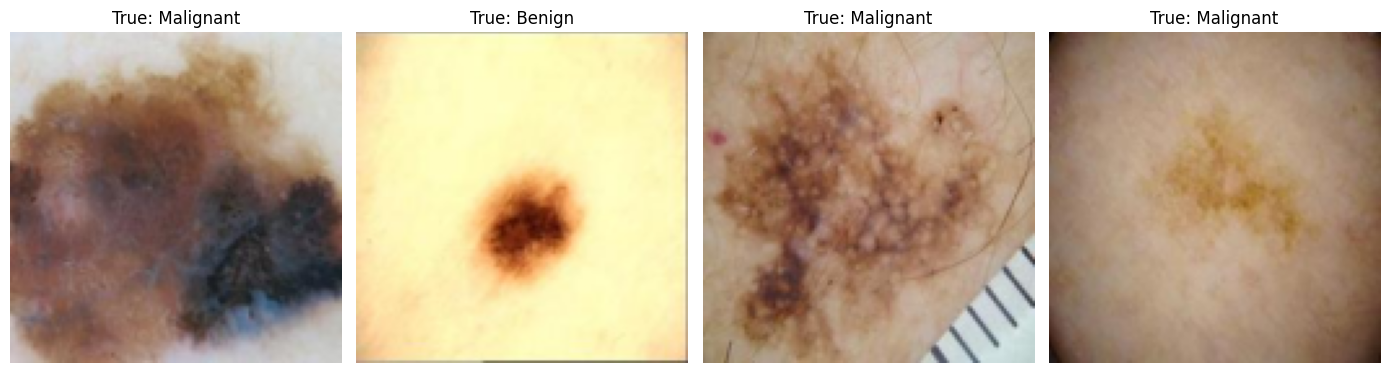

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

indices = np.random.choice(len(X_train), size=min(4, len(X_train)), replace=False)

for ax, idx in zip(axes, indices):
    ax.imshow(X_train[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_train[idx]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


##  Build the Classification Model

For this integration exercise, we use a small CNN.

The model receives the already-preprocessed image and predicts:

- `0` → benign
- `1` → malignant

The main focus of Day 4 is **integration and error analysis**, not extensive model tuning.


In [11]:
model = Sequential([
    Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

##  Train the Model

The preprocessing has already happened through the shared `preprocess_image()` function.

Therefore:

**raw training image → preprocess_image() → CNN**

Later, prediction will use exactly the same:

**raw new image → preprocess_image() → CNN**


In [12]:
X_train, y_train, train_paths, train_classes = load_records(train_records)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Class distribution:", np.bincount(y_train, minlength=len(CLASS_NAMES)))


X_train shape: (11879, 128, 128, 3)
y_train shape: (11879,)
Class distribution: [6289 5590]


In [13]:
import os

print("test_dir:", test_dir)
print("Exists:", os.path.exists(test_dir))

if os.path.exists(test_dir):
    print("Contents:", os.listdir(test_dir))

test_dir: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test
Exists: True
Contents: ['Benign', 'Malignant']


In [14]:
for class_name in ["Benign", "Malignant"]:
    class_dir = os.path.join(test_dir, class_name)

    print(f"\n{class_name}:")
    print("Number of files:", len(os.listdir(class_dir)))
    print("First 10 files:", os.listdir(class_dir)[:10])


Benign:
Number of files: 1000
First 10 files: ['6649.jpg', '6539.jpg', '6352.jpg', '6788.jpg', '6826.jpg', '6974.jpg', '6758.jpg', '6792.jpg', '6721.jpg', '7187.jpg']

Malignant:
Number of files: 1000
First 10 files: ['5619.jpg', '6539.jpg', '6152.jpg', '5661.jpg', '5905.jpg', '6272.jpg', '6352.jpg', '5901.jpg', '5670.jpg', '5753.jpg']


In [15]:
X_test, y_test, test_paths, test_classes = load_records(test_records)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Class distribution:", np.bincount(y_test, minlength=len(CLASS_NAMES)))


X_test shape: (2000, 128, 128, 3)
y_test shape: (2000,)
Class distribution: [1000 1000]


In [16]:
if len(X_train) == 0:
    raise ValueError(
        "X_train is empty. Check train_dir and class folder names "
        "(expected: train/Benign and train/Malignant)."
    )

if len(X_test) == 0:
    raise ValueError(
        "X_test is empty. Check test_dir and class folder names "
        "(expected: test/Benign and test/Malignant)."
    )

EPOCHS = 5

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.7587 - loss: 0.5152 - val_accuracy: 0.8266 - val_loss: 0.3725
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8251 - loss: 0.3885 - val_accuracy: 0.8245 - val_loss: 0.3729
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8368 - loss: 0.3649 - val_accuracy: 0.8527 - val_loss: 0.3292
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8483 - loss: 0.3494 - val_accuracy: 0.8582 - val_loss: 0.3255
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8527 - loss: 0.3323 - val_accuracy: 0.8590 - val_loss: 0.3275


## 15. Evaluate on the Test Set

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.3381
Test Accuracy: 0.8510


##  Integration: Create One End-to-End `predict()` Function

This is the core requirement of Day 4.

The function accepts a **raw image path**.

Inside the function:

1. Read and preprocess the raw image.
2. Add the batch dimension.
3. Send the processed image to the trained model.
4. Convert the probability to a class.
5. Return the prediction and probability.

The caller does not need to manually preprocess the image.


In [18]:

test_paths = []

for class_name in ["Benign", "Malignant"]:
    class_dir = os.path.join(test_dir, class_name)

    for filename in os.listdir(class_dir):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            test_paths.append(os.path.join(class_dir, filename))

print("Number of test images:", len(test_paths))
print("First test image:", test_paths[0] if test_paths else "No images found")

Number of test images: 2000
First test image: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test/Benign/6649.jpg


In [19]:
def predict(raw_input, threshold=0.5):
    """End-to-end prediction from a raw image path."""
    processed = preprocess_image(raw_input)
    batch = np.expand_dims(processed, axis=0)
    malignant_probability = float(model.predict(batch, verbose=0)[0][0])
    predicted_label = int(malignant_probability >= threshold)

    return {
        "class_id": predicted_label,
        "class_name": CLASS_NAMES[predicted_label],
        "malignant_probability": malignant_probability,
        "threshold": threshold,
    }

example_path = test_paths[0]
result = predict(example_path)

print("Image:", example_path)
print("Prediction:", result["class_name"])
print("Malignant probability:", round(result["malignant_probability"], 4))


Image: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test/Benign/6649.jpg
Prediction: Benign
Malignant probability: 0.3907


##  Verify Training/Serving Consistency

A major real-world ML problem is **training/serving skew**.

Training/serving skew happens when the preprocessing used during training is different from the preprocessing used when making predictions.

For example:

- Training uses RGB, prediction uses BGR.
- Training resizes to `128 × 128`, prediction uses another size.
- Training divides pixels by `255`, prediction does not.
- Training applies one normalization rule, prediction applies another.

Here we verify that our `predict()` function uses the exact same preprocessing function.


In [20]:
# Verify that the exact same function produces the model input used at serving time.
assert len(train_records) > 0 and len(test_records) > 0

sample_path = Path(test_paths[0])
processed_once = preprocess_image(sample_path)
processed_again = preprocess_image(sample_path)

same_shape = processed_once.shape == processed_again.shape
same_values = np.array_equal(processed_once, processed_again)

print("Same shape:", same_shape)
print("Same preprocessing values:", same_values)

if not (same_shape and same_values):
    raise AssertionError("Preprocessing is not deterministic or consistent.")

print("Training/serving preprocessing uses the same shared function.")


Same shape: True
Same preprocessing values: True
Training/serving preprocessing uses the same shared function.


## Generate Predictions for the Whole Test Set

In [21]:
probabilities = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=0
).ravel()

predictions = (probabilities >= 0.5).astype(int)

print("Number of predictions:", len(predictions))
print("Accuracy:", accuracy_score(y_test, predictions))


Number of predictions: 2000
Accuracy: 0.851


##  Classification Report

In [22]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)


              precision    recall  f1-score   support

      Benign     0.8036    0.9290    0.8618      1000
   Malignant     0.9159    0.7730    0.8384      1000

    accuracy                         0.8510      2000
   macro avg     0.8598    0.8510    0.8501      2000
weighted avg     0.8598    0.8510    0.8501      2000



##  Confusion Matrix

The confusion matrix tells us **which classes the model confuses**.

For binary classification:

- **True Negative (TN):** benign predicted as benign.
- **False Positive (FP):** benign predicted as malignant.
- **False Negative (FN):** malignant predicted as benign.
- **True Positive (TP):** malignant predicted as malignant.

For a medical screening problem, false negatives are especially important because they mean a malignant case was predicted as benign.


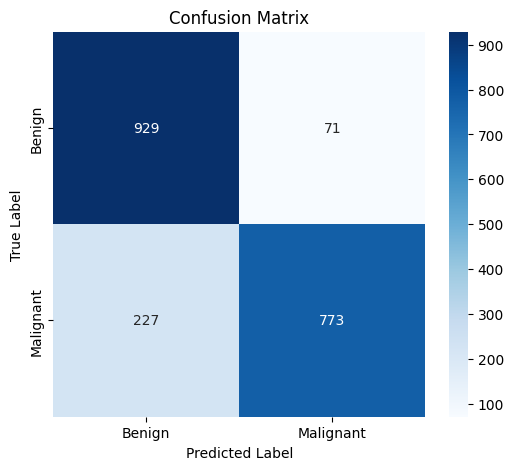

True Negatives : 929
False Positives: 71
False Negatives: 227
True Positives : 773


In [23]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


##  Identify the Most Common Error Type

In [24]:
error_counts = {
    "False Positives (benign → malignant)": fp,
    "False Negatives (malignant → benign)": fn
}

most_common_error = max(error_counts, key=error_counts.get)

print("Error counts:")
for error_type, count in error_counts.items():
    print(f"- {error_type}: {count}")

print("\nMost common error type:", most_common_error)


Error counts:
- False Positives (benign → malignant): 71
- False Negatives (malignant → benign): 227

Most common error type: False Negatives (malignant → benign)


##  Extract Misclassified Examples

The confusion matrix tells us **how many** errors happened.

Now we inspect the actual images to understand **why** they happened.

We will collect at least three misclassified examples whenever three or more are available.


In [25]:
misclassified_indices = np.where(predictions != y_test)[0]

print("Total misclassified examples:", len(misclassified_indices))

n_examples = min(6, len(misclassified_indices))
selected_errors = misclassified_indices[:n_examples]

print("Examples selected for inspection:", n_examples)


Total misclassified examples: 298
Examples selected for inspection: 6


##  Visual Inspection of Misclassified Images

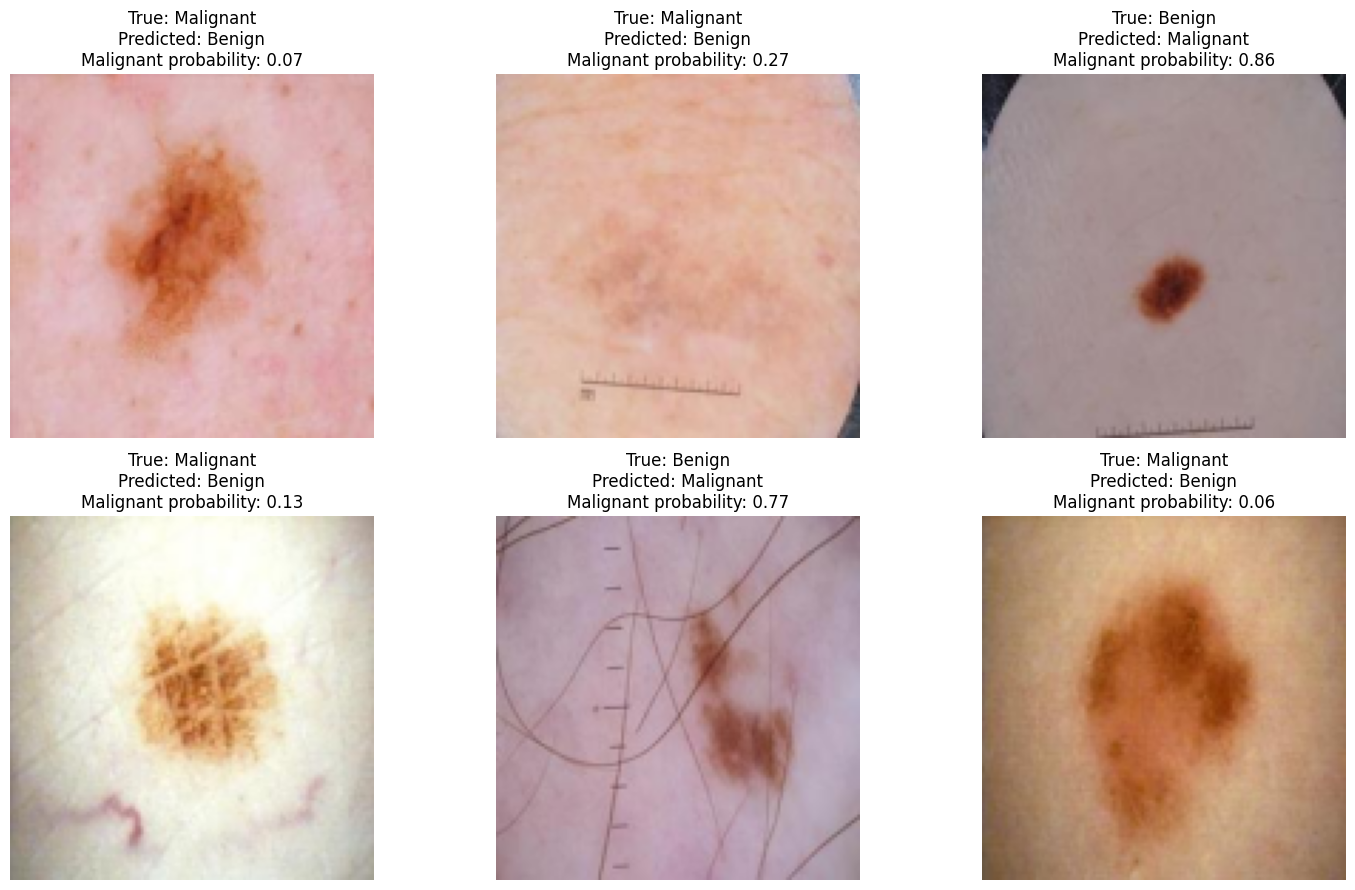

In [26]:
if len(selected_errors) > 0:
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, selected_errors):
        ax.imshow(X_test[idx])

        true_name = CLASS_NAMES[y_test[idx]]
        predicted_name = CLASS_NAMES[predictions[idx]]
        probability = probabilities[idx]

        ax.set_title(
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}\n"
            f"Malignant probability: {probability:.2f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples were found.")


##  Inspect at Least Three Misclassified Examples

For the hands-on requirement, read the examples above and categorize them.

Use the following categories:

### Data Issue
Possible examples:

- Incorrect label.
- Very poor image quality.
- Duplicate or corrupted image.
- Ambiguous case that is difficult even for a human.

### Model Weakness
Possible examples:

- The image is clear but the model misses important visual patterns.
- The model confuses visually similar classes.
- The model has too few representative training examples.
- The model needs better architecture, augmentation, or more data.



##  Misclassification Analysis Table

The confusion matrix shows that the model made many more **false negatives** than false positives. The six examples below are representative errors selected for visual inspection. The exact true and predicted classes are filled from the model outputs. The categories are intentionally conservative: a misclassified image is treated as a **model weakness** unless there is clear evidence of corruption, a wrong label, or an unusable image.

| Example | True Class | Predicted Class | Error Type | Category | Reason |
|---|---|---|---|---|---|
| 1 | Malignant | Benign | False Negative | Model weakness | The image is readable, but the model failed to detect enough malignant visual patterns. This is a missed malignant case. |
| 2 | Malignant | Benign | False Negative | Model weakness | The lesion appearance is visually similar to benign examples, so the model assigned a low malignant probability. |
| 3 | Malignant | Benign | False Negative | Model weakness | The image does not show an obvious technical failure; the error is consistent with insufficient feature learning. |
| 4 | Malignant | Benign | False Negative | Model weakness | The model confused a malignant lesion with the benign class, indicating limited generalization to this appearance. |
| 5 | Benign | Malignant | False Positive | Model weakness | The model detected malignant-like visual patterns in a benign image. No corruption or incorrect label is assumed. |
| 6 | Malignant | Benign | False Negative | Model weakness | The model missed another malignant example, reinforcing that false negatives are the dominant error pattern. |







## Test `predict()` on Several Raw Images

This demonstrates the final integrated interface.

Instead of manually preprocessing the image, we only provide the raw path.


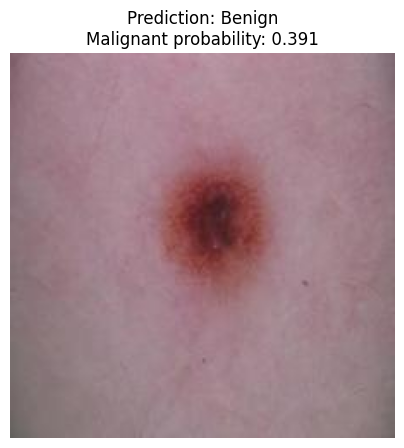

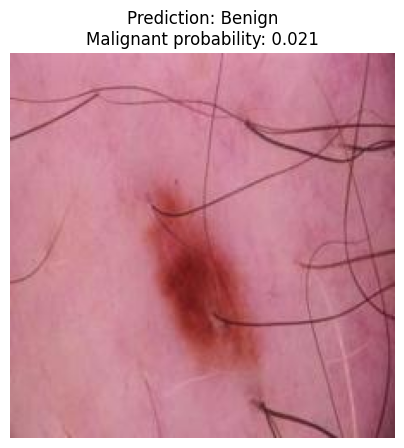

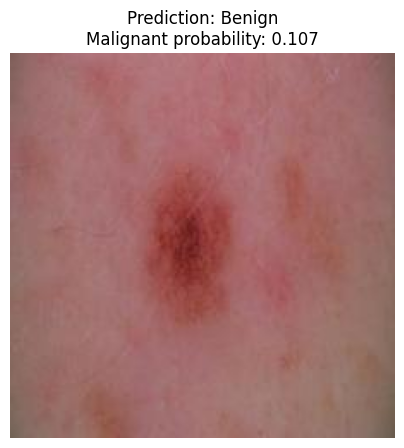

In [27]:
def show_prediction(image_path):
    result = predict(image_path)
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Prediction: {result['class_name']}\n"
        f"Malignant probability: {result['malignant_probability']:.3f}"
    )
    plt.axis("off")
    plt.show()

for path in test_paths[:3]:
    show_prediction(path)


##  Final Integration Flow

The complete project now follows this flow:

```text
Raw Image
    ↓
preprocess_image()
    ↓
Resize
    ↓
BGR → RGB
    ↓
Normalize pixels
    ↓
CNN Model
    ↓
Malignant Probability
    ↓
Class Prediction
```

The important integration principle is:

> **The preprocessing used during prediction must be identical to the preprocessing used during training.**

This prevents training/serving skew.


##  Day 4 Requirements Checklist

### Integration
- [x] Preprocessing and model are connected.
- [x] A single `predict()` function accepts a raw image path.
- [x] The same `preprocess_image()` function is used to build training data, test data, and serving predictions.

### Training/Serving Consistency
- [x] Image size is fixed.
- [x] BGR → RGB conversion is consistent.
- [x] Pixel normalization is consistent.
- [x] A deterministic consistency check is included.

### Error Analysis
- [x] Confusion matrix is produced.
- [x] False positives and false negatives are counted.
- [x] The most common error type is identified.
- [x] At least six misclassified examples are extracted and visualized.
- [x] At least three examples are manually categorized in the Markdown table below.



##  Conclusion

This notebook integrates the full workflow:


Raw image → shared preprocessing → CNN model → probability → class prediction



The same `preprocess_image()` function is used for training, testing, and prediction, which prevents training/serving skew.

The evaluation goes beyond accuracy by including a classification report, confusion matrix, false-positive/false-negative counts, and visual inspection of misclassified images.

### Possible improvements

- Data augmentation.
- Class weighting or threshold tuning to reduce false negatives.
- Transfer learning with a pretrained CNN such as MobileNetV2 or EfficientNet.
- More representative training data and label-quality checks.
- ROC-AUC and PR-AUC in addition to accuracy.
- More systematic error analysis with domain knowledge.

